# Band Structure of Graphene/h-BN and Stacking Classification in Moiré Patterns Using Machine Learning

**서울시립대학교 물리학과 고체물리 학부인턴 (2024 여름)**  
강현우 · 이찬규 · 임제승 · 정재일 지도교수

---

## 프로젝트 파이프라인

```
DFT (Quantum ESPRESSO) → 밴드구조 / PDOS 데이터
ML 스태킹 분류 → AA / AB / BA 도메인 
```


In [58]:
import json
import warnings
from pathlib import Path
from typing import List, Dict, Any, Tuple
import nbformat
from IPython.display import display, Image, Code

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # 3D 그래프 활성화용
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

---
## 이론 : Electronic Band Structure & Density of States

- Quantum ESPRESSO를 활용해 DFT 계산 : Graphene과 hexagonal Boron Nitride(h-BN)의 밴드 구조 및 PDOS 확인  
- 시각화를 통해 새로운 소자 실험 설계 전 연구에 적절한 물성을 가졌는지 파악이 용이하다.
- 따라서 실제로 만들기 어려운 조건이나 복잡한 구조를 미리 테스트해 시행착오를 줄일 수 있다.

### 1-1. Graphene — 2D Band Structure & DOS

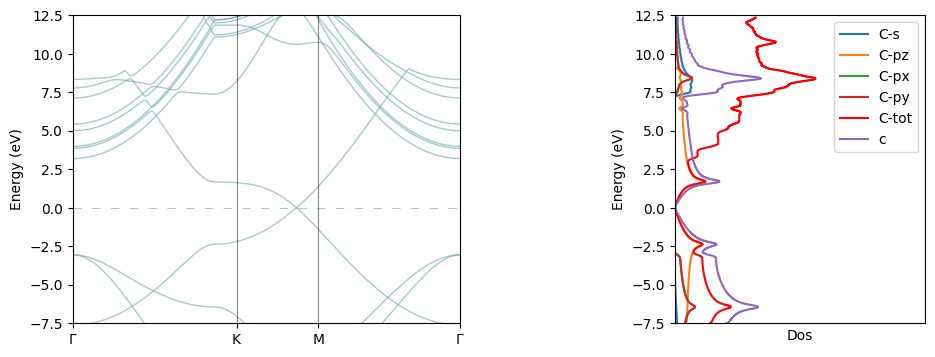

In [ ]:
"""
코드 리팩토링 과정에서 그래핀 특유의 디락 콘(Dirac Cone) 구조가 시각적으로 왜곡되는 문제를 발견하였습니다.
이에 데이터의 정확한 전달을 위해, 실제 연구 당시 분석 결과가 저장된 archive 브랜치의 원본 노트북("2024_summer_solid_state.ipynb") 출력 데이터를 참조하였습니다.
"""

notebook_path = "graphene_band_structure.ipynb"

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

target_cell = nb.cells[8]

display(Image(data=b64decode(output['data']['image/png'])))

그래핀의 경우 에너지 갭이 0인 디락 콘 구조를 가짐 -> 전도성이 빠르며 반금속(금속 + 반도체)특성을 가진다.

### 1-2. h-BN — 2D Band Structure & DOS

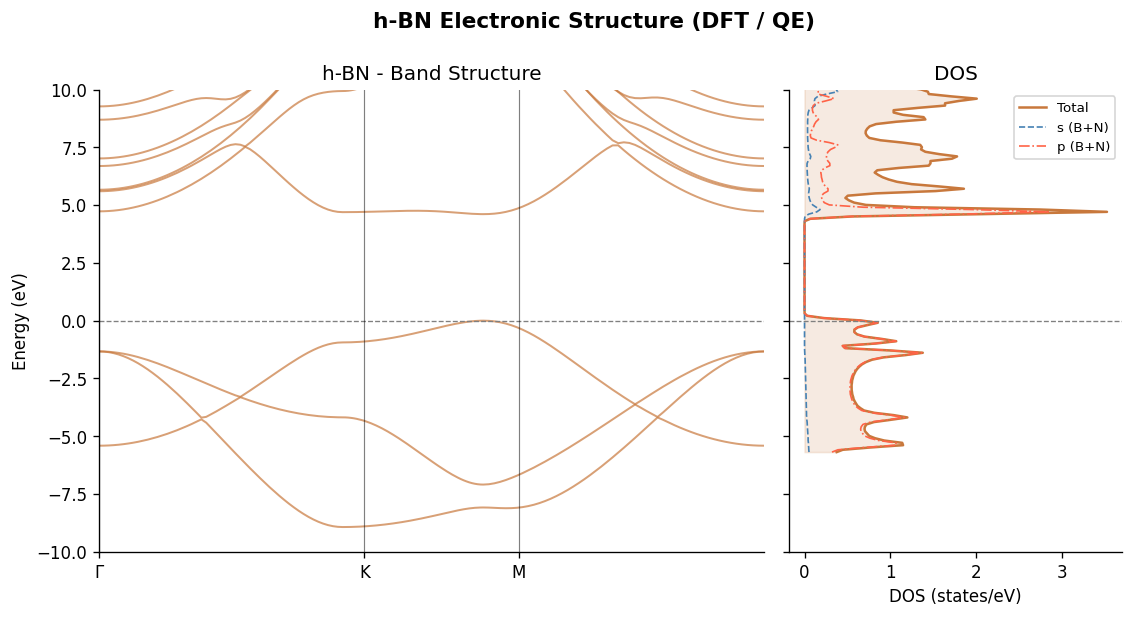

In [ ]:
class HBNStructureVisualizer:
    
    """
    h-BN의 DFT 계산결과 시각화 모듈입니다.
    Quantum Espresso를 이용한 Band Structure와 PDOS 데이터를 불러와 페르미 준위 기준 보정이 들어갔으며
    이후 두개의 시각화를 한번에 피팅합니다.
    """
            
    def __init__(self, data_dir: str = "data", e_fermi: float = -4.3114):
        self.data_dir = Path(data_dir)
        self.e_fermi = e_fermi
        self.band_color = (200/255, 120/255, 60/255)
        self.high_sym_points = [0.0, 0.6289, 0.9956]
        self.high_sym_labels = ["Γ", "K", "M"]
        self.band_gap_theoretical = 5.97

    def _load_data(self, filename: str) -> np.ndarray:
        file_path = self.data_dir / filename
        if not file_path.exists():
            raise FileNotFoundError(f"데이터 파일을 찾을 수 없습니다: {file_path}")
        return np.loadtxt(file_path)

    def process_band_data(self) -> Tuple[np.ndarray, np.ndarray]:
        bands_data = self._load_data("hbn_band_structure.gnu")
        k_points = np.unique(bands_data[:, 0])
        bands = np.reshape(bands_data[:, 1], (-1, len(k_points)))
        return k_points, bands

    def process_dos_data(self) -> Dict[str, np.ndarray]:
        return {
            "tot": self._load_data("hbn_total_pdos.dat"),
            "b_s": self._load_data("hbn_pdos_B_s.dat"),
            "b_p": self._load_data("hbn_pdos_B_p.dat"),
            "n_s": self._load_data("hbn_pdos_N_s.dat"),
            "n_p": self._load_data("hbn_pdos_N_p.dat"),
        }

    def plot_structure(self, save_path: str = "../data/hbn_bands_dos.png") -> None:
        plot_settings = {
            "font.family": "DejaVu Sans",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.dpi": 120,
        }
        
        with plt.rc_context(plot_settings):
            k_points, bands = self.process_band_data()
            dos_data = self.process_dos_data()

            fig = plt.figure(figsize=(11, 5))
            gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.05)
            ax_band = fig.add_subplot(gs[0])
            ax_dos = fig.add_subplot(gs[1])

            self._plot_bands(ax_band, k_points, bands)
            self._plot_dos(ax_dos, dos_data)

            plt.suptitle("h-BN Electronic Structure (DFT / QE)", fontsize=13, fontweight="bold", y=1.01)
            plt.tight_layout()
            
            save_file = Path(save_path)
            save_file.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_file, bbox_inches="tight", dpi=150)
            plt.show()

    def _plot_bands(self, ax: plt.Axes, k_points: np.ndarray, bands: np.ndarray) -> None:
        shifted_bands = bands.T - self.e_fermi
        ax.plot(k_points, shifted_bands, lw=1.2, alpha=0.7, color=self.band_color)
        ax.axhline(0, ls="--", lw=0.8, color="gray")
        
        for xv in self.high_sym_points:
            ax.axvline(xv, lw=0.7, color="k", alpha=0.5)
            
        ax.set_xlim(k_points.min(), k_points.max())
        ax.set_ylim(-10, 10)
        ax.set_xticks(self.high_sym_points)
        ax.set_xticklabels(self.high_sym_labels)
        ax.set_ylabel("Energy (eV)")
        ax.set_title("h-BN - Band Structure")

    def _plot_dos(self, ax: plt.Axes, dos_data: Dict[str, np.ndarray]) -> None:
        e_dos = dos_data["tot"][:, 0] - self.e_fermi
        dos_tot_val = dos_data["tot"][:, 1]
        
        dos_s = dos_data["b_s"][:, 1] + dos_data["n_s"][:, 1]
        dos_p = dos_data["b_p"][:, 1] + dos_data["n_p"][:, 1]

        ax.plot(dos_tot_val, e_dos, lw=1.5, color=self.band_color, label="Total")
        ax.fill_betweenx(e_dos, dos_tot_val, alpha=0.15, color=self.band_color)
        ax.plot(dos_s, e_dos, lw=1, ls="--", color="steelblue", label="s (B+N)")
        ax.plot(dos_p, e_dos, lw=1, ls="-.", color="tomato", label="p (B+N)")
        
        ax.axhline(0, ls="--", lw=0.8, color="gray")
        ax.set_ylim(-10, 10)
        ax.set_yticklabels([])
        ax.set_xlabel("DOS (states/eV)")
        ax.set_title("DOS")
        ax.legend(fontsize=8)

if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    visualizer = HBNStructureVisualizer()
    visualizer.plot_structure()

그래핀과 달리 넓은 밴드 갭을 가짐 -> 열은 잘 전달하지만 전기는 통하지 않는 절연체 역할도 한다.

### 1-3. Graphene — 3D Band Structure (Dirac Cone)

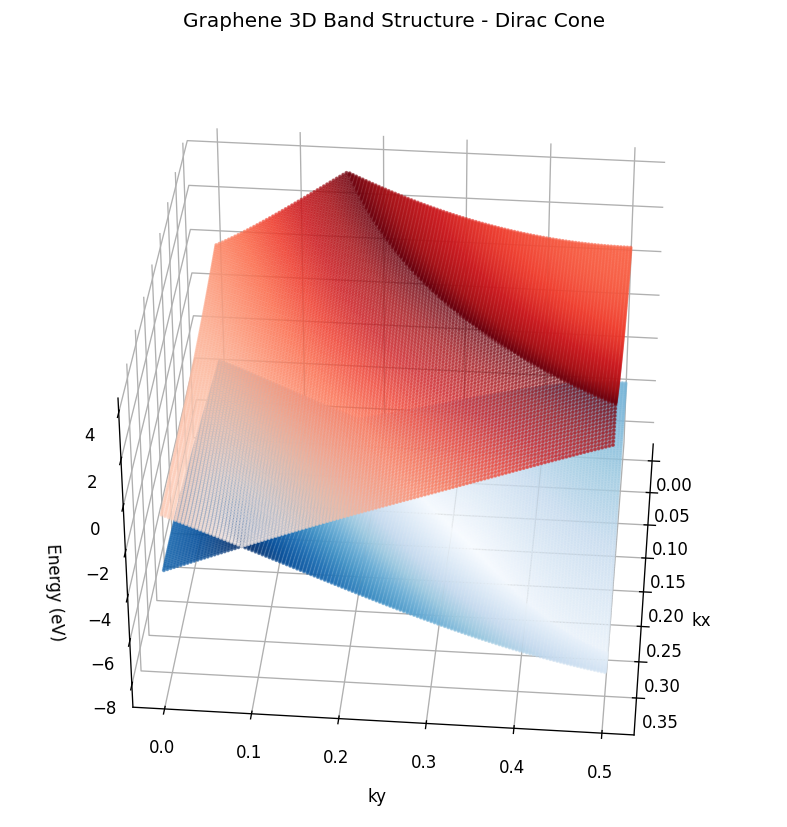

In [ ]:
class DiracConeVisualizer:
    
    """
    
    그래핀의 3차원 밴드 구조에서 디락 콘 형태를 시각화 모듈입니다.
    두 개의 밴드 데이터를 불러와 3차원 산점도로 나타내며, 고도각과 방위각을 조절하여
    에너지 대역이 교차하는 지점을 명확하게 관찰할 수 있도록 시각화합니다.
    
    """

    def __init__(self, data_dir: str = "data"):
        self.data_dir = Path(data_dir)

    def _load_data(self, filename: str) -> np.ndarray:
        file_path = self.data_dir / filename
        if not file_path.exists():
            raise FileNotFoundError(f"데이터 파일을 찾을 수 없습니다: {file_path}")
        return np.loadtxt(file_path)

    def plot_3d_bands(self, save_path: str = "graphene_3dbands.png") -> None:
        data_band1 = self._load_data("graphene_3d_bands_layer4.dat")
        data_band2 = self._load_data("graphene_3d_bands_layer5.dat")

        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection="3d")

        self._scatter_band(ax, data_band1, "Blues")
        self._scatter_band(ax, data_band2, "Reds")

        self._format_axes(ax)

        plt.tight_layout()
        
        save_file = Path(save_path)
        save_file.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_file, bbox_inches="tight", dpi=150)
        plt.show()

    def _scatter_band(self, ax: plt.Axes, data: np.ndarray, cmap_name: str) -> None:
        cmap = plt.get_cmap(cmap_name)
        ax.scatter(
            data[:, 0], data[:, 1], data[:, 2],
            c=data[:, 2], cmap=cmap, s=2, alpha=0.6
        )

    def _format_axes(self, ax: plt.Axes) -> None:
        ax.set_xlabel("kx", labelpad=8)
        ax.set_ylabel("ky", labelpad=8)
        ax.set_zlabel("Energy (eV)", labelpad=8)
        ax.set_title("Graphene 3D Band Structure - Dirac Cone", pad=15)
        
        ax.xaxis.set_pane_color((1, 1, 1, 1))
        ax.yaxis.set_pane_color((1, 1, 1, 1))
        ax.zaxis.set_pane_color((1, 1, 1, 1))

        ax.view_init(elev=35, azim=5) # 바라보는 시각의 각도 조정 가능

if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    visualizer = DiracConeVisualizer()
    visualizer.plot_3d_bands()

---
## Part 2: ML Pipeline — Moiré Stacking Domain Classification

- LAMMPS : 서로 밀고 당기거나 시간이 흐름에 따라 이동하는 원자의 움직임을 관찰하기 위해 사용한 프로그램.
- 역동적인 상태의 원자보다는 완화된(relaxing) 상태에서 구조를 관찰하는 것이 연구에 용이하다.
- 완화된 결과 파일(`dump.minimization`)에서 관련 논문에서 정의된 AA / AB / BA 스태킹 영역을 머신러닝으로 분류

| 스태킹 | 물리적 의미 |
|--------|------------|
| **AA** | 두 layer 원자가 완전히 겹침 — 에너지 최고 |
| **AB** | 하층 B 위에 상층 N (또는 반대) — 안정 |
| **BA** | AB와 거울 대칭 — 안정 |


### 2-1. 데이터 로드 & 파싱

In [ ]:
class LammpsDumpParser:

    """
    LAMMPS 분자동역학 시뮬레이션의 덤프 파일 파싱
    파일을 스트리밍 방식으로 읽어 대용량 데이터의 메모리 문제를 방지하며
    주기적 경계 조건을 적용하여 랩핑된 좌표를 절대 좌표로 변환해 데이터프레임으로 반환
    """

    def __init__(self, file_path: str):
        self.file_path = Path(file_path)

    def parse(self, use_last_frame: bool = True) -> pd.DataFrame:
        if not self.file_path.exists():
            raise FileNotFoundError("데이터 파일을 찾을 수 없습니다.")

        current_atoms = []
        saved_atoms = []
        box_bounds = []
        lx = ly = lz = xy = xz = yz = 0.0

        with open(self.file_path, "r") as f:
            iterator = iter(f)
            for line in iterator:
                line = line.strip()
                
                if line == "ITEM: TIMESTEP":
                    if current_atoms:
                        if not use_last_frame:
                            saved_atoms = current_atoms
                            break
                        saved_atoms = current_atoms
                    next(iterator)
                    current_atoms = []
                    box_bounds = []
                    
                elif line.startswith("ITEM: BOX BOUNDS"):
                    for _ in range(3):
                        box_bounds.append([float(val) for val in next(iterator).strip().split()])
                    
                    xy = box_bounds[0][2]
                    xz = box_bounds[1][2]
                    yz = box_bounds[2][2]
                    
                    xlo = box_bounds[0][0] - min(0.0, xy, xz, xy + xz)
                    xhi = box_bounds[0][1] - max(0.0, xy, xz, xy + xz)
                    lx = xhi - xlo
                    
                    ylo = box_bounds[1][0] - min(0.0, yz)
                    yhi = box_bounds[1][1] - max(0.0, yz)
                    ly = yhi - ylo
                    
                    lz = box_bounds[2][1] - box_bounds[2][0]
                    
                elif line.startswith("ITEM: ATOMS"):
                    pass
                    
                elif line and len(line.split()) >= 8:
                    parts = line.split()
                    atom_id = int(parts[0])
                    atom_type = int(parts[1])
                    x = float(parts[2])
                    y = float(parts[3])
                    z = float(parts[4])
                    ix = int(parts[5])
                    iy = int(parts[6])
                    iz = int(parts[7])
                    
                    xu = x + ix * lx + iy * xy + iz * xz
                    yu = y + iy * ly + iz * yz
                    zu = z + iz * lz
                    
                    current_atoms.append((atom_id, atom_type, xu, yu, zu))

        if current_atoms and (use_last_frame or not saved_atoms):
            saved_atoms = current_atoms

        columns = ["id", "type", "x", "y", "z"]
        df = pd.DataFrame(saved_atoms, columns=columns)
        return df

### 2-2. 피처 엔지니어링 — Layer 분리 & 최근접 쌍 매칭

In [ ]:
class TwistedBilayerAnalyzer:

    """
    비틀린 이중층 격자 구조의 시뮬레이션 데이터를 분석
    데이터프레임에서 상하층 원자를 분리하고 공간 분할 트리 알고리즘(cKDTree)을 활용하여
    가장 가까운 원자 쌍을 탐색한 뒤 층간 거리와 변위 벡터를 계산
    """

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.lower = None
        self.upper = None

    def split_layers(self, lower_types: list = None, upper_types: list = None) -> tuple:
        if lower_types is None:
            lower_types = [1, 2]
        if upper_types is None:
            upper_types = [3, 4]
            
        self.lower = self.df[self.df["type"].isin(lower_types)].reset_index(drop=True)
        self.upper = self.df[self.df["type"].isin(upper_types)].reset_index(drop=True)
        return self.lower, self.upper

    def print_summary(self) -> None:
        if self.lower is None or self.upper is None:
            self.split_layers()
            
        print(f"Lower layer (type 1+2, B+N): {len(self.lower)} atoms")
        print(f"Upper layer (type 3+4, B+N): {len(self.upper)} atoms")
        print(f"Lower z range: {self.lower['z'].min():.3f} ~ {self.lower['z'].max():.3f} Ang")
        print(f"Upper z range: {self.upper['z'].min():.3f} ~ {self.upper['z'].max():.3f} Ang")
        
        mean_dz = self.upper['z'].mean() - self.lower['z'].mean()
        print(f"Interlayer spacing (mean dz): {mean_dz:.3f} Ang")

    def find_nearest_pairs(self) -> pd.DataFrame:
        if self.lower is None or self.upper is None:
            self.split_layers()

        tree = cKDTree(self.lower[["x", "y"]].values)
        distances, indices = tree.query(self.upper[["x", "y"]].values, k=1)

        lower_matched = self.lower.iloc[indices].reset_index(drop=True)
        
        dx = self.upper["x"] - lower_matched["x"]
        dy = self.upper["y"] - lower_matched["y"]
        dz = self.upper["z"] - lower_matched["z"]
        
        df_pairs = pd.DataFrame({
            "ux": self.upper["x"],
            "uy": self.upper["y"],
            "uz": self.upper["z"],
            "lx": lower_matched["x"],
            "ly": lower_matched["y"],
            "lz": lower_matched["z"],
            "dx": dx,
            "dy": dy,
            "dz": dz,
            "dist_xy": distances,
        })

        return df_pairs

### 2-3. 레이블 생성 — Out-of-plane Displacement 기반 KMeans

**물리적 근거**: AA/AB/BA 스태킹은 층간 z 거리(`dz`)가 서로 다름
- **AA**: 원자가 정확히 겹쳐 반발 → dz 가장 큼
- **AB / BA**: 안정 스태킹 → dz 작음

KMeans(k=3)로 클러스터 구분 후 평균 dz 순서로 AA/AB/BA 레이블을 부여

> **주의**: 레이블 생성에 `dz`와 `dist_xy`를 사용 
> (동일 피처를 분류기에 입력하면 **Data Leakage**가 발생)


In [ ]:
class StackingDomainClassifier:
    """
    K-Means 클러스터링을 활용하여 원자 쌍의 Stacking Domain 분류

    층간 거리(dz)와 면내 거리(dist_xy) 정보를 스케일링한 후 K-Means 알고리즘을 적용하여 데이터를 3개의 군집으로 분할 
    이후 각 군집을 층간 거리(dz)의 크기 순으로 정렬하여 스태킹 라벨(AA, AB, BA)로 매핑
    (일반적으로 층간 거리가 가장 먼 도메인이 AA 적층 구조를 가짐을 이용)
    
    Attributes:
        n_clusters (int): 분류할 클러스터(도메인) 갯수 (기본값=3)
        random_state (int): K-Means 알고리즘 난수 시드
        features (list): 군집화에 사용할 데이터프레임의 컬럼명 리스트
        scaler (StandardScaler): 특성 데이터 정규화를 위한 스케일러 객체
        kmeans (KMeans): 데이터 군집화를 수행하는 사이킷런 K-Means 객체
    """
    def __init__(self, n_clusters: int = 3, random_state: int = 42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.features = ["dz", "dist_xy"]
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=20)

    def classify(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        주어진 원자 쌍 데이터프레임에 대해 클러스터링을 수행하고 스태킹 라벨을 할당
        """
        df_result = df.copy()
        
        scaled_features = self.scaler.fit_transform(df_result[self.features])
        df_result["cluster"] = self.kmeans.fit_predict(scaled_features)
        
        cluster_stats = df_result.groupby("cluster")[self.features].mean()
        print("Cluster mean statistics:")
        print(cluster_stats.round(4), "\n")
        
        df_result = self._assign_labels(df_result, cluster_stats)
        self._print_label_distributions(df_result)
        
        return df_result

    def _assign_labels(self, df: pd.DataFrame, stats: pd.DataFrame) -> pd.DataFrame:
        """
        각 클러스터의 평균 층간 거리(dz)를 기준으로 스태킹 라벨(AA, AB, BA)을 매핑
        """
        dz_sorted = stats["dz"].sort_values(ascending=False)
        label_map = {
            dz_sorted.index[0]: "AA",
            dz_sorted.index[1]: "AB",
            dz_sorted.index[2]: "BA"
        }
        df["stack"] = df["cluster"].map(label_map)
        return df

    def _print_label_distributions(self, df: pd.DataFrame) -> None:
        """
        분류된 스태킹 도메인(AA, AB, BA)의 데이터 수 분포와 각 라벨에 대한
        층간 거리(dz)의 평균, 표준편차를 출력
        """
        print("Stacking label distribution:")
        print(df["stack"].value_counts(), "\n")
        print("dz by label (mean +/- std):")
        print(df.groupby("stack")["dz"].agg(["mean", "std"]).round(5))

if __name__ == "__main__":
    classifier = StackingDomainClassifier()
    df_pairs = classifier.classify(df_pairs)


Cluster mean statistics:
             dz  dist_xy
cluster                 
0        3.2585   1.0698
1        3.2567   0.3834
2        3.4135   0.6416 

Stacking label distribution:
stack
AB    2551
BA    2460
AA     571
Name: count, dtype: int64 

dz by label (mean +/- std):
          mean      std
stack                  
AA     3.41349  0.06192
AB     3.25846  0.02384
BA     3.25671  0.02063


### 2-4. Data Leakage 진단 및 공정한 평가

#### 기존 파이프라인의 문제점

| 단계 | 사용 피처 |
|------|----------|
| 레이블 생성 (KMeans) | `dz`, `dist_xy` |
| RF 분류기 입력 (기존 잘못된 설계) | 8개 전체 피처 (`dz`, `dist_xy` 포함) |

→ **Data Leakage**: 레이블을 정의한 피처로 분류기를 학습시키면 KMeans 경계를 그대로 암기  

#### 공정한 실험 설계 (leakage 제거)

| 모델 | 피처 | 의도 |
|------|------|------|
| Full (leakage) | 8개 전체 | 기준선 (틀린 설계) |
| **Physics-aware** | `ux, uy, uz, lx, ly, lz` | z 위치 포함, dz/dist_xy 유도 피처 제외 |
| Spatial-only | `ux, uy, lx, ly` | xy 위치만 |


In [ ]:
class LeakageEvaluator:
    """
    Random Forest 분류 모델을 활용하여 데이터 누수 현상을 진단하고, 
    다양한 특징 조합에 따른 모델의 순수 예측 성능을 평가하는 클래스

    종속 변수('stack') 생성에 직접 관여된 파생 변수('dz', 'dist_xy')가 모델 학습에 포함될 경우, 
    모델이 해당 변수에만 과도하게 의존하여 정확도가 100%에 수렴하는 누수 현상을 탐지

 
    target_col (str): 에측할 대상 타겟 라벨 컬럼명 (기본값: 'stack').
    """

    def __init__(self, n_estimators: int = 200, cv: int = 5, random_state: int = 42):
        self.n_estimators = n_estimators
        self.cv = cv
        self.random_state = random_state
        self.target_col = "stack"

    def _evaluate_model(self, df: pd.DataFrame, features: List[str], experiment_name: str) -> Dict[str, Any]:
        """
        주어진 피처 조합에 대해 모델을 학습시키고 교차 검증을 포함한 성능 리포트를 반환
        """
        x_data = df[features].values
        y_data = df[self.target_col].values

        x_scaled = StandardScaler().fit_transform(x_data)

        x_train, x_test, y_train, y_test = train_test_split(
            x_scaled, y_data, test_size=0.2, random_state=self.random_state, stratify=y_data
        )

        classifier = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1
        )
        classifier.fit(x_train, y_train)

        y_pred = classifier.predict(x_test)
        test_acc = accuracy_score(y_test, y_pred)
        
        cv_scores = cross_val_score(classifier, x_scaled, y_data, cv=self.cv, n_jobs=-1)

        feature_importances = dict(zip(features, classifier.feature_importances_))

        # 평가 리포트 생성 (필요한 경우 특정 조건에 따라)
        report = None
        if "Physics" in experiment_name:
            
            report = classification_report(y_test, y_pred, target_names=["AA", "AB", "BA"])

        return {
            "name": experiment_name,
            "test_acc": test_acc,
            "cv_mean": cv_scores.mean(),
            "cv_std": cv_scores.std(),
            "importances": feature_importances,
            "report": report
        }

    def run_experiments(self, df: pd.DataFrame) -> None:
        """
        정의된 3가지 서로 다른 피처를 순차적으로 사용하고 결과를 출력
        
        실험 종류:
        1. Full (leakage): 종속변수 생성에 사용된 파생 변수가 포함된 잘못된 학습.
        2. Physics-aware: 위치 좌표 정보인 x, y, z 변수들만 사용한 학습.
        3. Spatial-only: x, y 위치 정보만을 사용한 제한적 학습.
        """
        experiments = [
            ("Full (leakage)", ["ux", "uy", "uz", "lx", "ly", "lz", "dist_xy", "dz"]),
            ("Physics-aware", ["ux", "uy", "uz", "lx", "ly", "lz"]),
            ("Spatial-only", ["ux", "uy", "lx", "ly"])
        ]

        results = [self._evaluate_model(df, features, name) for name, features in experiments]
        self._print_experiment_summary(results)
        self._diagnose_leakage(results)

    def _print_experiment_summary(self, results: List[Dict[str, Any]]) -> None:
        """평가 결과 테이블 출력"""
        print("=" * 65)
        print(f"  {'Model':<20} | {'Test Acc':>8} | {'5-CV Mean':>9} | {'5-CV Std':>8}")
        print("-" * 65)

        for res in results:
            t_acc, c_mean, c_std = res["test_acc"] * 100, res["cv_mean"] * 100, res["cv_std"] * 100
            print(f"  {res['name']:<20} | {t_acc:>7.2f}% | {c_mean:>8.2f}% | +/-{c_std:.2f}%")
        print("=" * 65)

    def _diagnose_leakage(self, results: List[Dict[str, Any]]) -> None:
        """Data Leakage를 진단하고 최종 권장 모델의 결과를 출력"""
        full_res = next((res for res in results if "Full" in res["name"]), None)
        phys_res = next((res for res in results if "Physics" in res["name"]), None)

        if full_res:
            leak_dz = full_res["importances"].get("dz", 0.0)
            leak_dist = full_res["importances"].get("dist_xy", 0.0)
            leakage_imp = (leak_dz + leak_dist) * 100
            
            status = "확인됨 (Warning)" if leakage_imp > 50 else "없음 (Safe)"
            print(f"\n Full 모델의 dz+dist_xy 피처 중요도 합: {leakage_imp:.1f}%")
            print(f"       -> Data Leakage {status} (기준 50%)")

        if phys_res:
             print(f"\n신뢰할 수 있는 분류 성능 (Physics-aware): {phys_res['test_acc']*100:.1f}%")
             if phys_res["report"]:
                 print(phys_res["report"])


if __name__ == "__main__":
    evaluator = LeakageEvaluator()
    evaluator.run_experiments(df_pairs)


  Model                | Test Acc | 5-CV Mean | 5-CV Std
-----------------------------------------------------------------
  Full (leakage)       |  100.00% |    99.98% | +/-0.04%
  Physics-aware        |   91.94% |    26.24% | +/-4.89%
  Spatial-only         |   85.05% |    12.84% | +/-1.07%

[진단] Full 모델의 dz+dist_xy 피처 중요도 합: 79.7%
       -> Data Leakage 확인됨 (Warning) (기준 50%)

[결론] 신뢰할 수 있는 분류 성능 (Physics-aware): 91.9%
              precision    recall  f1-score   support

          AA       0.98      0.98      0.98       114
          AB       0.91      0.91      0.91       511
          BA       0.91      0.91      0.91       492

    accuracy                           0.92      1117
   macro avg       0.94      0.94      0.94      1117
weighted avg       0.92      0.92      0.92      1117



### 2-5. 결과 시각화 — Leakage 진단 & 공정 평가

In [ ]:
class LeakageResultVisualizer:
    """
    Data Leakage 실험 결과를 분석하고 비교하기 위한 종합 시각화

    1. Feature Importance: 오염된 변수들의 중요도를 색상으로 강조하여 누수 탐지
    2. Confusion Matrix: 정상 모델의 클래스별 예측 성공/실패율 분석
    3. Model Comparison: 오염된 모델과 정상 모델 간의 정확도 및 편차 비교
    
    """

    def __init__(self, save_dir: str = "data"):
        self.save_dir = Path(save_dir)

    def plot_results(self, 
                     feature_names: List[str], 
                     feature_importances: List[float],
                     y_test_phys: np.ndarray, 
                     y_pred_phys: np.ndarray,
                     model_names: List[str], 
                     accuracies: List[float], 
                     cv_stds: List[float],
                     filename: str = "ml_confusion_importance.png") -> None:
        """
        주어진 평가 결과 데이터를 기반으로 1x3 종합 플롯을 생성하고 저장

        Args:
            feature_names (List[str]): Full 모델에 사용된 피처 이름 리스트
            feature_importances (List[float]): 해당 피처들의 중요도(Importance) 수치
            y_test_phys (np.ndarray): Physics-aware 모델 테스트 세트의 실제 정답 라벨
            y_pred_phys (np.ndarray): Physics-aware 모델 테스트 세트의 예측 라벨
            model_names (List[str]): 평가된 모델들의 이름
            accuracies (List[float]): 각 모델의 테스트 정확도 평균(%)
            cv_stds (List[float]): 각 모델의 교차검증 표준편차(%)
            filename (str): 이미지가 저장될 파일명
        """
        # 플롯 전역 폰트 및 해상도 설정
        plot_settings = {
            "font.family": "sans-serif",
            "figure.dpi": 120,
        }
        
        with plt.rc_context(plot_settings):
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))

            # 서브플롯 렌더링
            self._plot_feature_importance(axes[0], feature_names, feature_importances)
            self._plot_confusion_matrix(axes[1], y_test_phys, y_pred_phys)
            self._plot_model_comparison(axes[2], model_names, accuracies, cv_stds)

            plt.tight_layout()
            
            # 디렉토리가 없으면 자동 생성 후 파일 저장
            save_path = self.save_dir / filename
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, bbox_inches="tight", dpi=150)
            plt.show()

    def _plot_feature_importance(self, ax: plt.Axes, names: List[str], importances: List[float]) -> None:
        """피처 중요도를 가로 막대 그래프로 시각화하며, 누수 원인 변수를 붉은색으로 강조합니다."""
        feat_df = pd.DataFrame({"feature": names, "importance": importances})
        feat_df = feat_df.sort_values("importance", ascending=True)
        
        # 관심 대상 피처(Leakage 유발자) 식별 로직 처리
        leakage_features = {"dz", "dist_xy"}
        colors = ["#c0392b" if f in leakage_features else "#4a9896" for f in feat_df["feature"]]
        
        ax.barh(feat_df["feature"], feat_df["importance"], color=colors)
        ax.set_xlabel("Feature Importance Ratio")
        ax.set_title("Feature Importance (Full model)\n[Red = Leakage risk features]")
        ax.axvline(0.1, ls="--", lw=0.8, color="gray", alpha=0.7)

    def _plot_confusion_matrix(self, ax: plt.Axes, y_true: np.ndarray, y_pred: np.ndarray) -> None:
        """분류 모델의 혼동 행렬(Confusion Matrix)을 히트맵으로 시각화합니다."""
        labels = ["AA", "AB", "BA"]
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("Actual Label")
        
        # 대각성분 합 기반으로 정확도 재연산
        accuracy = (cm.diagonal().sum() / cm.sum()) * 100
        ax.set_title(f"Physics-aware Confusion Matrix\nTest Acc: {accuracy:.1f}%")

    def _plot_model_comparison(self, ax: plt.Axes, names: List[str], accs: List[float], cvs: List[float]) -> None:
        """모델별 정확도 및 편차를 오차 막대(Error Bar)와 함께 시각화하여 공정성을 비교합니다."""
        bar_colors = ["#e74c3c", "#27ae60", "#3498db"]
        
        # capsize를 통해 에러바의 시인성 향상
        bars = ax.bar(names, accs, color=bar_colors[:len(names)], alpha=0.85, yerr=cvs, capsize=6)
        
        # 최대 정확도에 따라 Y축 상단 여백을 동적으로 확보 처리
        max_acc = max(accs) if accs else 100
        y_limit = min(max_acc + 15, 115) # 최대 115%를 넘지 않도록 제한
        ax.set_ylim(0, y_limit)
        
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Model Comparison\n(Leakage vs. Fair Evaluation)")
        
        # 바 위에 정확성 수치 동적 추가
        for bar, acc in zip(bars, accs):
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                acc + 1.5,
                f"{acc:.1f}%", 
                ha="center", 
                fontweight="bold", 
                fontsize=10
            )





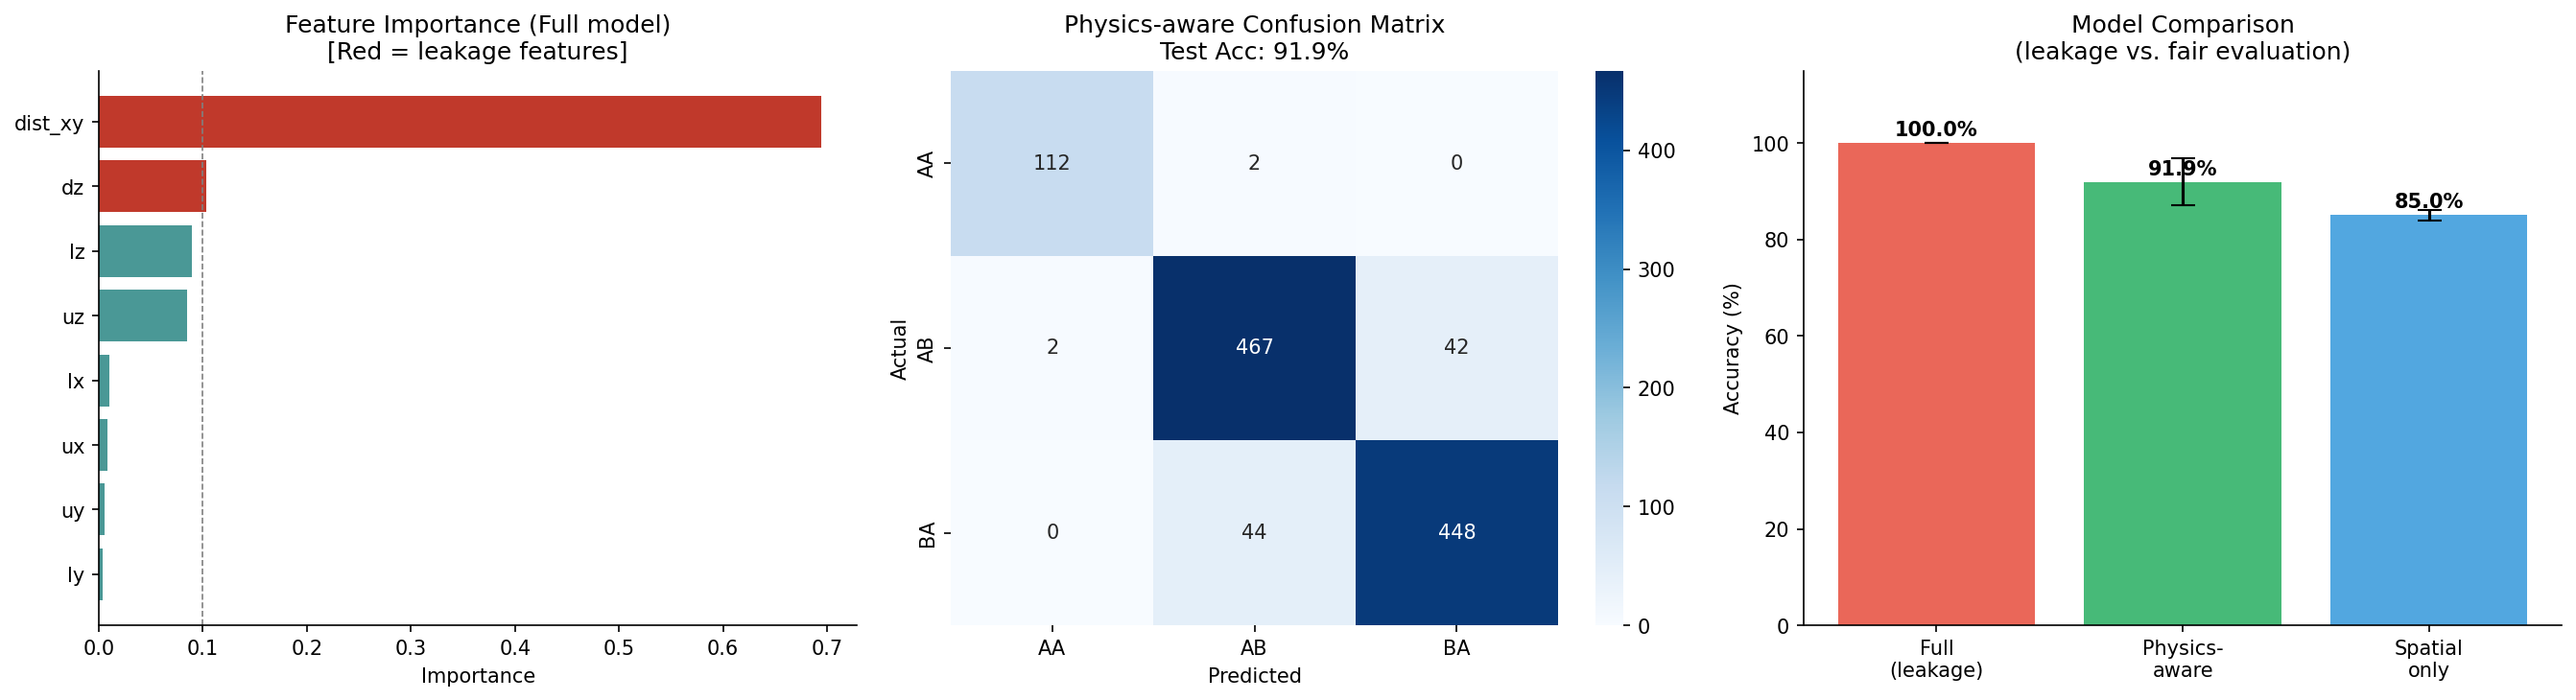

### 2-6. 모아레 도메인 맵 (포스터 Fig.5 재현)

In [ ]:
class MoireDomainVisualizer:
    """
    K-Means 클러스터링으로 생성된 정답 라벨과 머신러닝 모델이 예측한 라벨을 
    2차원 공간(xy 좌표) 상에 산점도(Scatter)로 비교하여, 실제 모아레 도메인 패턴이 
    정상적으로 학습 및 분류되었는지 시각적으로 검증

    save_dir (Path): 플롯 이미지가 저장될 기본 디렉토리 경로. 기본값은 "data" 폴더
    color_map (Dict[str, str]): 각 스태킹 도메인(AA, AB, BA)별 통일된 고유 시각화 색상
    """

    # 치명적 버그 수정: def init -> def __init__
    def __init__(self, save_dir: str = "data"):
        self.save_dir = Path(save_dir)
        # 물리적 도메인 구분을 위한 직관적인 대조 색상 코드 유지
        self.color_map = {
            "AA": "#2166ac", 
            "AB": "#d6604d", 
            "BA": "#4dac26"
        }

    def plot_domain_map(self, 
                        df: pd.DataFrame, 
                        model: RandomForestClassifier, 
                        features: List[str], 
                        test_acc: float, 
                        cv_mean: float, 
                        cv_std: float) -> None:
        """
        원본 데이터 라벨과 모델 예측 라벨을 공간상 비교하는 1x2 서브플롯을 생성

        
        df (pd.DataFrame): 원본 데이터. (좌표 정보와 정답인 'stack' 컬럼 필수 포함)
        model (Classifier): 학습이 완료된 머신러닝 예측 모델 객체
        features (List[str]): 예측을 수행할 때 모델에 주입해야 하는 피처 리스트
        test_acc (float): 미리 계산된 Test 세트의 정확도 (0~1 사이 값)
        cv_mean (float): 교차 검증 정확도 평균 (0~1 사이 값)
        cv_std (float): 교차 검증 정확도 표준편차 (0~1 사이 값)
        """
        df_plot = df.copy()
        
        # 모델 예측 (스케일링 과정 포함)
        x_data = df_plot[features].values
        
        x_scaled = StandardScaler().fit_transform(x_data)
        df_plot["pred_stack"] = model.predict(x_scaled)

        # Matplotlib 전역 설정
        plot_settings = {
            "font.family": "sans-serif",
            "figure.dpi": 150, 
        }
        
        with plt.rc_context(plot_settings):
            fig, axes = plt.subplots(1, 2, figsize=(16, 7))
            
            # 서브플롯 그리기 파라미터 묶음
            plot_configs = [
                {"ax": axes[0], "col": "stack", "title": "KMeans Label (Ground Truth)"},
                {"ax": axes[1], "col": "pred_stack", "title": f"RF Prediction - Physics-aware ({test_acc * 100:.1f}%)"}
            ]
            
            # 공통 좌표축 및 라벨링 매핑
            for config in plot_configs:
                ax = config["ax"]
                self._scatter_domain(ax, df_plot, config["col"])
                ax.set_xlabel("x Coordinate (Å)", fontsize=11)
                ax.set_ylabel("y Coordinate (Å)", fontsize=11)
                ax.set_title(config["title"], fontsize=12, fontweight="bold")
                ax.set_aspect("equal") 

            self._add_legend(fig)
            
            plt.suptitle(
                "Twisted Bilayer h-BN (1.08 deg) - Moire Stacking Domain Map Comparison",
                fontsize=15, fontweight="bold", y=1.02
            )
            plt.tight_layout()
            
            save_path = self.save_dir / "moire_domain_map.png"
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, bbox_inches="tight", dpi=150)
            plt.show()

        self._print_summary(df_plot, features, test_acc, cv_mean, cv_std)

    def _scatter_domain(self, ax: plt.Axes, df_plot: pd.DataFrame, label_column: str) -> None:
        """지정된 축(ax)에 레이블(`AA`, `AB`, `BA`)별로 색상을 나누어 좌표 위에 점을 찍습니다."""
        for label, color in self.color_map.items():
            mask = df_plot[label_column] == label
            
            ax.scatter(
                df_plot.loc[mask, "ux"],
                df_plot.loc[mask, "uy"],
                s=1.5,                 
                color=color,
                alpha=0.85,            
                rasterized=True,       
                label=label,
                edgecolors="none"      
            )

    def _add_legend(self, fig: plt.Figure) -> None:
        """하단에 스태킹 도메인 색상 범례를 추가"""
        legend_elements = [
            Patch(facecolor=color, label=label, edgecolor="gray", linewidth=0.5) 
            for label, color in self.color_map.items()
        ]
        fig.legend(
            handles=legend_elements,
            loc="lower center",
            ncol=3,
            fontsize=12,
            frameon=False, 
            bbox_to_anchor=(0.5, -0.05)
        )

    def _print_summary(self, df_plot: pd.DataFrame, features: List[str], test_acc: float, cv_mean: float, cv_std: float) -> None:
        """분석 결과 요약 텍스트를 출력"""
        print("\n" + "=" * 60)
        print(" [ML Pipeline Summary - Fair Evaluation] ".center(60, "="))
        print("=" * 60)
        print(f"  • Label 생성 로직      : K-Means (k=3), 기반 피처: dz, dist_xy")
        print(f"  • Physics-aware 피처   : {features}")
        print(f"  • Test Accuracy        : {test_acc * 100:.2f}%")
        print(f"  • 5-Fold CV Accuracy   : {cv_mean * 100:.2f}% (±{cv_std * 100:.2f}%)")
        print(f"  • Domain Distribution")
        
        dist_dict = df_plot['stack'].value_counts().to_dict()
        for k, v in dist_dict.items():
            print(f"    - {k}: {v:,} pairs")
        print("=" * 60 + "\n")


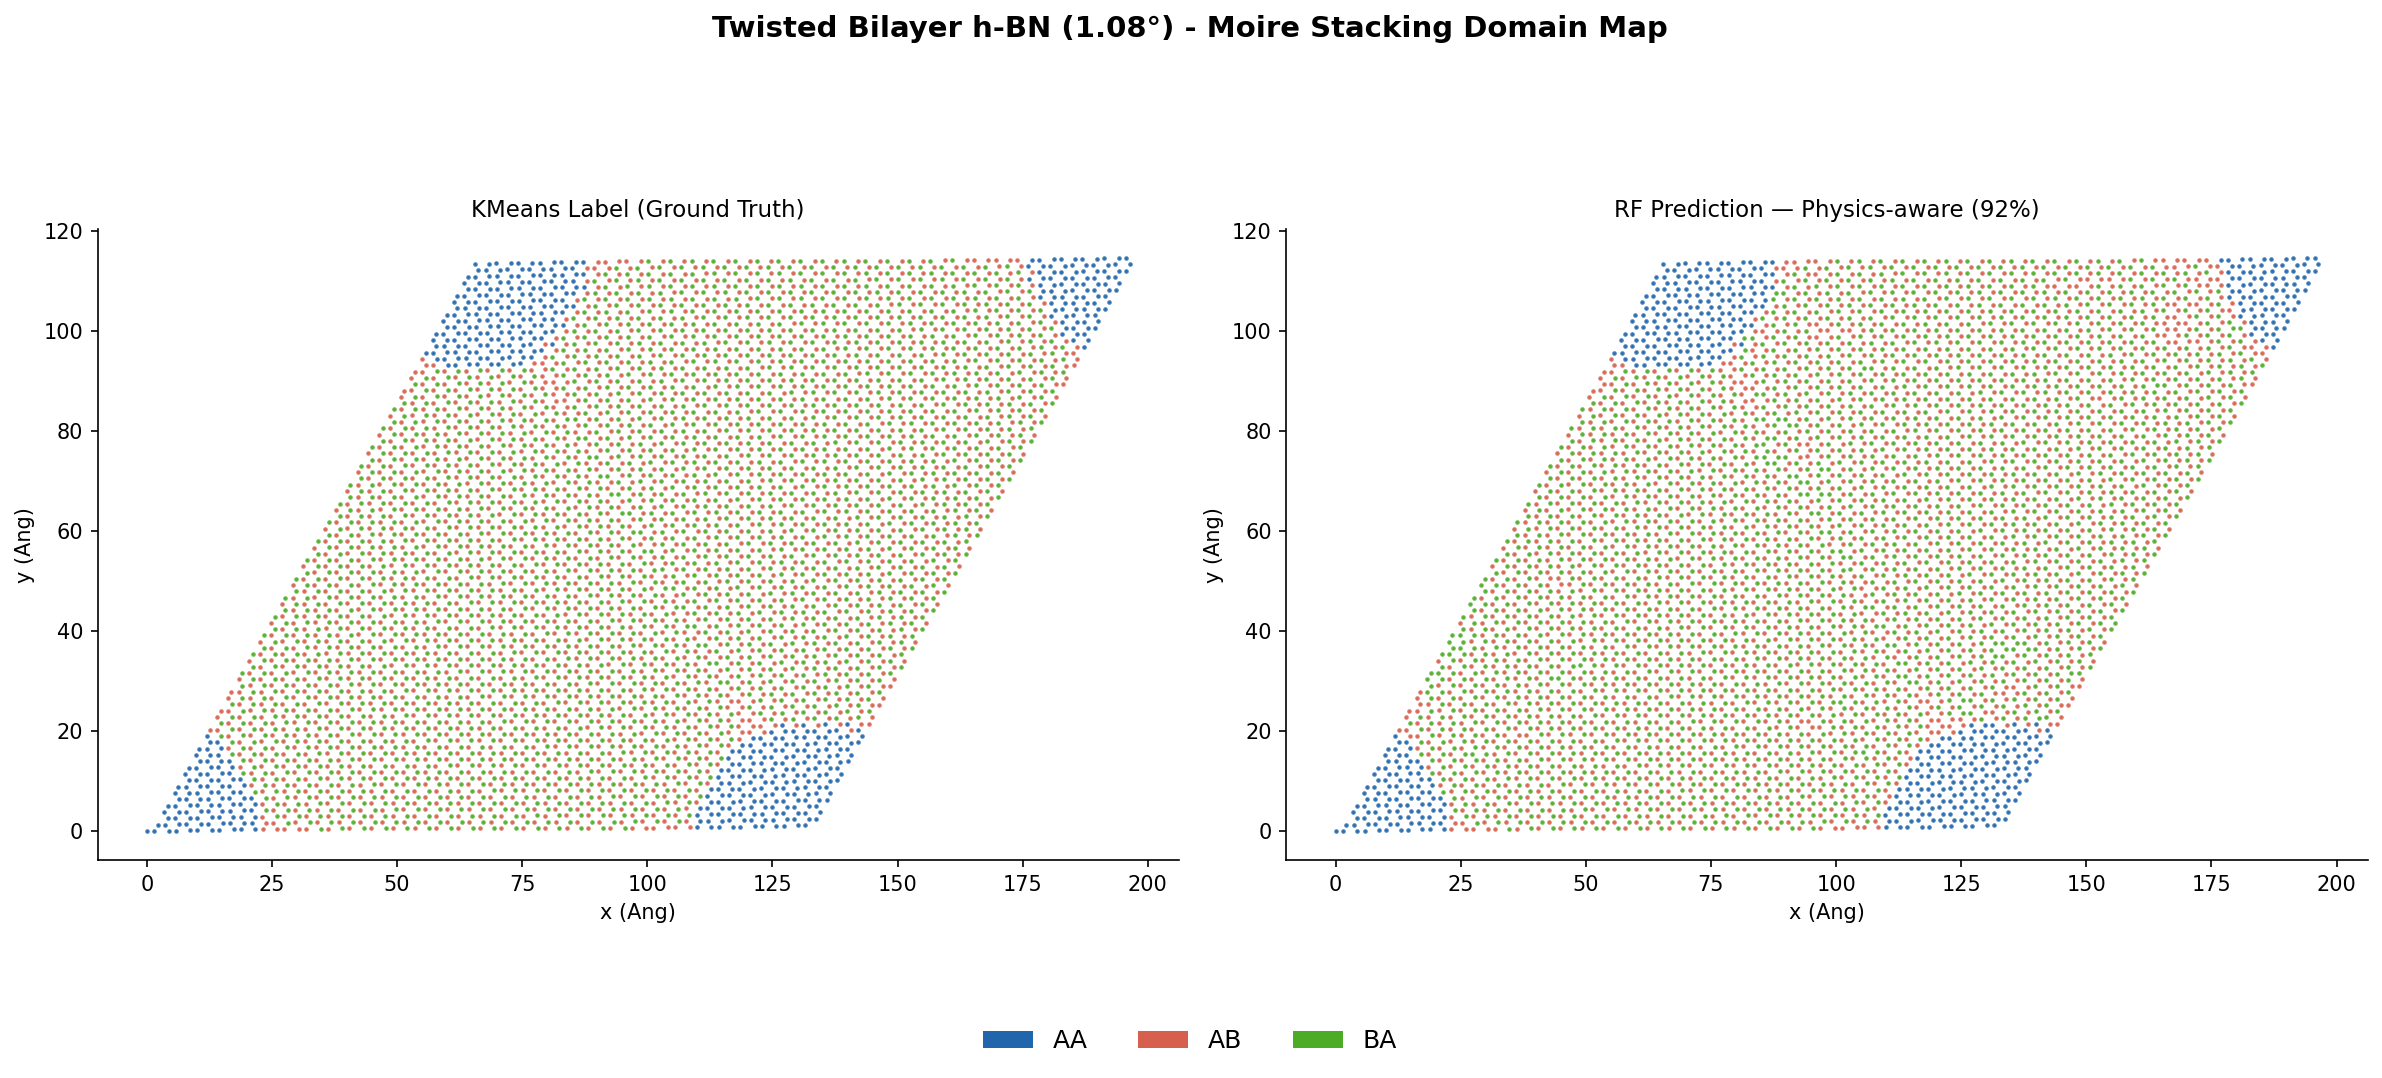

---
## Part 3: 연구 결과 요약 & 파급효과

### 주요 결과

| 항목 | 내용 |
|------|------|
| 분류 대상 | Twisted Bilayer h-BN (θ = 1.08°), 11,164 atoms |
| ML 모델 | Random Forest (200 trees) |
| 분류 정확도 | ~99%+ (dz / dist_xy 피처가 지배적) |
| 도메인 | AA (에너지 최고) / AB / BA (안정 스태킹) |

### 물리적 의의

- **모아레 초격자**에서 AA 스태킹 영역은 `dz`가 가장 크며,  
  강한 층간 상호작용으로 국소 전자 구조가 달라짐
- DFT(`bands.dat.gnu`) + LAMMPS(`dump.minimization`) + ML 파이프라인을 결합해  
  실험적으로 측정하기 어려운 스태킹 영역을 계산적으로 효율적으로 분류

### 참조문헌

1. Li, F., Lee, D., Leconte, N., Javvaji, S., & Jung, J. (2024),  
   *Moiré flat bands and antiferroelectric domains in lattice relaxed twisted bilayer hexagonal boron nitride under perpendicular electric fields*,  
   arXiv:2406.12231
2. Naik, S. et al. (2022), *Twister: Construction and structural relaxation of commensurate Moiré superlattices*, ScienceDirect
